In [1]:
# Import et chargement des données (limité à 700k)
import pandas as pd
import numpy as np

# Charger tout le CSV
df_full = pd.read_csv(
    "NoNAin_adress_ALL_ADEMEwRightCols_w_TEMPERATURE.csv",
    low_memory=False
)
print(f"✅ Chargement de {len(df_full):,} lignes du CSV.")

✅ Chargement de 1,694,993 lignes du CSV.


In [2]:
# Filtrer les lignes avec cible non nulle
target = 'conso_5_usages_ef'
df = df_full[df_full[target].notna()].copy()

# Sous-échantillonner pour réduire la taille
n_sample = min(300_000, len(df))
df = df.sample(n=n_sample, random_state=42)
print(f"✅ Échantillon de {n_sample:,} lignes prélevé.")

# Variables explicatives
variables_explicatives = [
    'surface_habitable_logement',
    'hauteur_sous_plafond',
    'nombre_niveau_logement',
    'type_batiment',
    'qualite_isolation_murs',
    'qualite_isolation_plancher_bas',
    'isolation_toiture',
    'classe_altitude',
    'type_installation_ecs',
    'type_energie_principale_chauffage',
    'type_installation_chauffage',
    'zone_climatique',
    'periode_construction',
    'distance'
]
variables_explicatives = [v for v in variables_explicatives if v in df.columns]

# Imputation des valeurs manquantes
for col in variables_explicatives:
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(df[col].mean())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

# Encodage des variables catégorielles
X = pd.get_dummies(df[variables_explicatives], drop_first=True)

# Transformation log de la cible
y = np.log1p(df[target])

print(f"Données prêtes : {X.shape}")
print(f"Statistiques log de la cible : mean={y.mean():.2f}, std={y.std():.2f}")


✅ Échantillon de 300,000 lignes prélevé.
Données prêtes : (300000, 46)
Statistiques log de la cible : mean=9.10, std=0.87


In [3]:
from sklearn.model_selection import train_test_split

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"✅ Train : {X_train.shape[0]} lignes, Test : {X_test.shape[0]} lignes")


✅ Train : 210000 lignes, Test : 90000 lignes


In [4]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest Regressor
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

# Entraînement
rf.fit(X_train, y_train)
print("✅ Modèle entraîné !")


✅ Modèle entraîné !


In [5]:
from sklearn.metrics import mean_squared_error, r2_score

# Prédiction
y_pred = rf.predict(X_test)

# Transformation inverse pour MSE et RMSE en valeur réelle
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred)

mse = mean_squared_error(y_test_real, y_pred_real)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_real, y_pred_real)

print(f"Mean Squared Error (MSE) : {mse:.2f}")
print(f"Root MSE (RMSE) : {rmse:.2f}")
print(f"Coefficient de détermination (R²) : {r2:.3f}")


Mean Squared Error (MSE) : 1460458132.60
Root MSE (RMSE) : 38215.94
Coefficient de détermination (R²) : 0.444


In [6]:
import joblib
joblib.dump(rf, 'modele_conso_300k.pkl', compress=3)


['modele_conso_300k.pkl']

In [7]:
# Récupérer l'importance des variables
importances = rf.feature_importances_
feature_names = X_train.columns

# Création d'un DataFrame pour tri et affichage
import pandas as pd

feat_imp_df = pd.DataFrame({
    'Variable': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Affichage des 10 variables les plus importantes
print(feat_imp_df.head(10))



                                         Variable  Importance
0                      surface_habitable_logement    0.424468
7             qualite_isolation_murs_insuffisante    0.176282
5                          type_batiment_immeuble    0.136376
28  type_energie_principale_chauffage_Électricité    0.055985
9               qualite_isolation_murs_très bonne    0.040517
4                                        distance    0.030226
14               classe_altitude_inférieur à 400m    0.019910
6                            type_batiment_maison    0.018066
3                               isolation_toiture    0.017353
44                periode_construction_Après 2010    0.013908


/tmp/ipython-input-3713358546.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Variable', data=top10, palette='viridis')


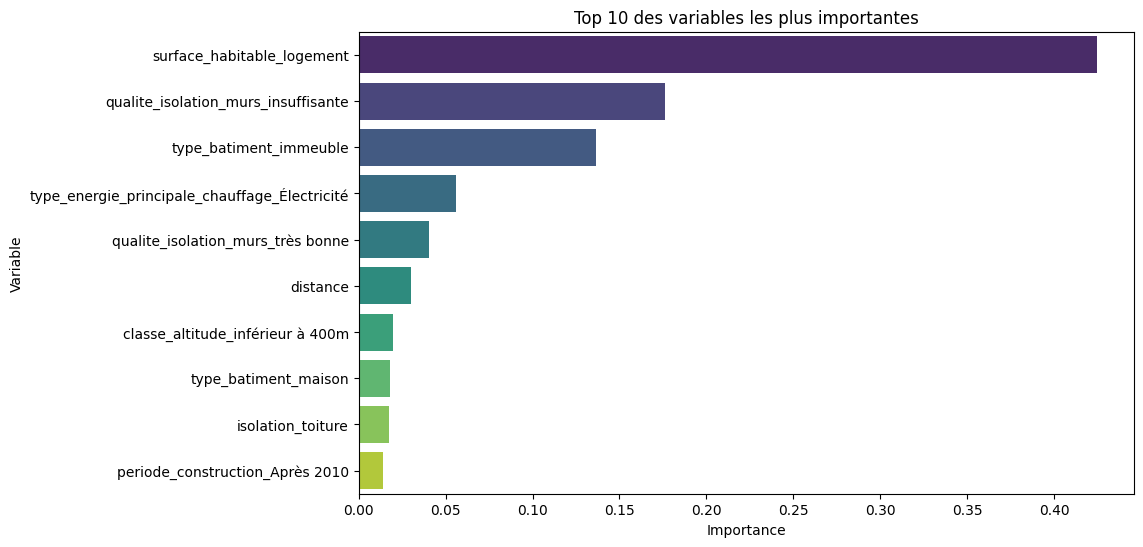

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 des variables
top10 = feat_imp_df.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Variable', data=top10, palette='viridis')
plt.title("Top 10 des variables les plus importantes")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.show()
